In [155]:
import pandas as pd
import glob
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [156]:
dataframes = []
paths = glob.glob('/Users/connorhall/datasets/inst414/module 4 assignment/*.csv')
for csv in paths:
    df = pd.read_csv(csv)
    dataframes.append(df)
    
combined_df = pd.concat(dataframes, axis=0, ignore_index=True)


## verify output

In [157]:
for dataframe in dataframes:
    print(dataframe[:3][['STATE', 'EVENT_TYPE']])
    print('Length:',len(dataframe),'\n')

       STATE         EVENT_TYPE
0  TENNESSEE            Tornado
1  TENNESSEE            Tornado
2  TENNESSEE  Thunderstorm Wind
Length: 61389 

     STATE         EVENT_TYPE
0  GEORGIA  Thunderstorm Wind
1   KANSAS               Hail
2   KANSAS               Hail
Length: 61281 

    STATE  EVENT_TYPE
0  NEVADA   High Wind
1  NEVADA  Heavy Snow
2  NEVADA  Heavy Snow
Length: 69887 

          STATE  EVENT_TYPE
0  NORTH DAKOTA  Heavy Snow
1  NORTH DAKOTA  Heavy Snow
2  NORTH DAKOTA  Heavy Snow
Length: 75593 

      STATE EVENT_TYPE
0  NEBRASKA       Hail
1  NEBRASKA       Hail
2  NEBRASKA       Hail
Length: 62699 

       STATE         EVENT_TYPE
0   OKLAHOMA  Thunderstorm Wind
1  LOUISIANA     Excessive Heat
2     OREGON         Heavy Snow
Length: 69801 

      STATE         EVENT_TYPE
0   GEORGIA  Thunderstorm Wind
1  MICHIGAN            Tornado
2  VIRGINIA       Winter Storm
Length: 72241 

          STATE   EVENT_TYPE
0         TEXAS  Flash Flood
1  SOUTH DAKOTA        Flood
2       A

In [158]:
combined_df

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202112,11,349,202112,11,350,165322,999750,TENNESSEE,47,2021,December,Tornado,C,165,SUMNER,OHX,11-DEC-21 03:49:00,CST-6,11-DEC-21 03:50:00,0,0,0,0,10.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF0,1.72,50.0,OHX,TN,189.0,WILSON,3.22,WNW,HUNTERS PT,2.52,NW,HUNTERS PT,36.3178,-86.3235,36.3296,-86.2965,One of the worst tornado outbreaks ever record...,This small EF-0 tornado was determined through...,CSV
1,202112,11,249,202112,11,254,165322,999613,TENNESSEE,47,2021,December,Tornado,C,43,DICKSON,OHX,11-DEC-21 02:49:00,CST-6,11-DEC-21 02:54:00,0,0,0,0,10.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF0,5.41,175.0,NaN,NaN,NaN,NaN,1.43,ENE,TIDWELL,2.11,ESE,BAKERSWORKS,36.0255,-87.3054,36.0736,-87.2330,One of the worst tornado outbreaks ever record...,This tornado developed just southeast of the D...,CSV
2,202112,11,325,202112,11,327,165322,999636,TENNESSEE,47,2021,December,Thunderstorm Wind,C,37,DAVIDSON,OHX,11-DEC-21 03:25:00,CST-6,11-DEC-21 03:27:00,0,0,0,0,250.00K,0.00K,NWS Storm Survey,74.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.69,NW,MAPLEWOOD,2.05,SW,AMQUI,36.2372,-86.7286,36.2572,-86.7035,One of the worst tornado outbreaks ever record...,Severe straight-line winds caused significant ...,CSV
3,202112,11,232,202112,11,239,165322,999604,TENNESSEE,47,2021,December,Tornado,C,81,HICKMAN,OHX,11-DEC-21 02:32:00,CST-6,11-DEC-21 02:39:00,0,0,0,0,50.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,8.54,400.0,NaN,NaN,NaN,NaN,3.67,NW,SPOT,3.92,NNW,PINEWOOD,35.9205,-87.6423,35.9725,-87.5068,One of the worst tornado outbreaks ever record...,This tornado touched down in far northwest Hic...,CSV
4,202112,6,724,202112,6,724,165321,999306,TENNESSEE,47,2021,December,Thunderstorm Wind,C,49,FENTRESS,OHX,06-DEC-21 07:24:00,CST-6,06-DEC-21 07:24:00,0,0,0,0,3.00K,0.00K,Social Media,52.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.15,W,JAMESTOWN,1.15,W,JAMESTOWN,36.4322,-84.9405,36.4322,-84.9405,After some isolated thunderstorms moved across...,A Facebook report indicated trees and power li...,CSV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653796,201606,22,1831,201606,22,1832,107879,646877,ILLINOIS,17,2016,June,Tornado,C,103,LEE,LOT,22-JUN-16 18:31:00,CST-6,22-JUN-16 18:32:00,0,0,0,0,NaN,NaN,NWS Storm Survey,NaN,NaN,NaN,NaN,EF0,0.10,50.0,NaN,NaN,NaN,NaN,1.44,NE,WEST BROOKLYN,1.54,NE,WEST BROOKLYN,41.7134,-89.1286,41.7133,-89.1261,"The evening of Wednesday, June 22 brought a fa...",This tornado was determined form ground survey...,CSV
653797,201606,22,1859,201606,22,1900,107879,647802,ILLINOIS,17,2016,June,Tornado,C,99,LA SALLE,LOT,22-JUN-16 18:59:00,CST-6,22-JUN-16 19:00:00,0,0,0,0,NaN,NaN,Storm Chaser,NaN,NaN,NaN,NaN,EF0,0.30,75.0,NaN,NaN,NaN,NaN,3.37,NNE,EARLVILLE,3.10,NNE,EARLVILLE,41.6233,-88.8999,41.6190,-88.9003,"The evening of Wednesday, June 22 brought a fa...",This tornado was determined from video documen...,CSV
653798,201606,22,2149,201606,22,2150,107879,648267,ILLINOIS,17,2016,June,Tornado,C,105,LIVINGSTON,LOT,22-JUN-16 21:49:00,CST-6,22-JUN-16 21:50:00,0,0,0,0,0.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF0,0.10,10.0,NaN,NaN,NaN,NaN,2.13,NNW,CHATSWORTH,2.07,NNW,CHATSWORTH,40.7769,-88.2997,40.7763,-88.2989,"The evening of Wednesday, June 22 brought a fa...",At a residence one tenth of 

## calculate # of weather events per state

In [159]:
# count number of events per state
event_count = pd.crosstab(combined_df['STATE'], combined_df['EVENT_TYPE']).stack('EVENT_TYPE')
# get lists of states and events
states = event_count.index.get_level_values('STATE').tolist()
events = event_count.index.get_level_values('EVENT_TYPE').tolist()

events_df = pd.DataFrame({'State': states, 'Event': events})
# get list of # of events
events_df['Count'] = event_count.values
events_df

,State,Event,Count
0,ALABAMA,Astronomical Low Tide,1
1,ALABAMA,Avalanche,0
2,ALABAMA,Blizzard,0
3,ALABAMA,Coastal Flood,28
4,ALABAMA,Cold/Wind Chill,132
...,...,...,...
3721,WYOMING,Volcanic Ashfall,0
3722,WYOMING,Waterspout,0
3723,WYOMING,Wildfire,78
3724,WYOMING,Winter Storm,1961


## create weather event count list for each state/location

In [160]:
unique_events = events_df['Event'].unique().tolist()
unique_states = events_df['State'].unique().tolist()

counts = []
for st in unique_states:
    st_filter = events_df[events_df['State'] == st]
    counts.append(st_filter['Count'].tolist())

In [161]:
# add count lists to dataframe
state_events = pd.DataFrame(counts, columns=unique_events, index=unique_states)
pd.options.display.max_columns = None
state_events

,Astronomical Low Tide,Avalanche,Blizzard,Coastal Flood,Cold/Wind Chill,Debris Flow,Dense Fog,Dense Smoke,Drought,Dust Devil,Dust Storm,Excessive Heat,Extreme Cold/Wind Chill,Flash Flood,Flood,Freezing Fog,Frost/Freeze,Funnel Cloud,Hail,Heat,Heavy Rain,Heavy Snow,High Surf,High Wind,Hurricane (Typhoon),Ice Storm,Lake-Effect Snow,Lakeshore Flood,Lightning,Marine Dense Fog,Marine Hail,Marine High Wind,Marine Hurricane/Typhoon,Marine Lightning,Marine Strong Wind,Marine Thunderstorm Wind,Marine Tropical Depression,Marine Tropical Storm,Rip Current,Seiche,Sleet,Sneakerwave,Storm Surge/Tide,Strong Wind,Thunderstorm Wind,Tornado,Tropical Depression,Tropical Storm,Tsunami,Volcanic Ashfall,Waterspout,Wildfire,Winter Storm,Winter Weather
ALABAMA,1,0,0,28,132,0,0,0,857,1,0,202,19,944,242,13,380,18,1237,408,61,75,1,36,7,9,0,0,86,0,0,0,0,0,0,0,0,0,24,0,6,0,32,198,7391,861,18,138,0,0,0,0,98,168
ALASKA,2,21,468,58,24,16,0,0,0,0,0,0,18,2,175,0,23,1,5,0,3,414,11,647,0,17,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3,5,7,1,0,0,2,2,0,22,350,165
AMERICAN SAMOA,0,0,0,4,0,0,0,0,1,0,0,1,0,83,10,0,0,1,0,3,60,0,34,27,2,0,0,0,4,0,0,0,0,0,0,0,0,0,4,0,0,0,1,26,10,0,0,1,6,0,0,0,0,0
ARIZONA,0,7,0,0,32,18,47,0,384,14,431,1808,5,2002,178,1,4,56,351,725,190,373,0,432,0,1,0,0,67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,1508,58,0,0,0,0,0,184,72,25
ARKANSAS,0,0,0,0,64,0,0,0,388,0,5,587,12,1301,966,1,0,31,2011,1203,228,155,0,24,0,83,0,0,38,0,0,0,0,0,0,0,0,0,0,0,3,0,0,52,3415,445,3,39,0,0,0,6,484,850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGINIA,6,3,19,241,177,23,762,0,88,0,0,145,39,1857,2232,0,509,33,1193,303,1497,244,0,529,0,83,0,0,138,0,0,0,0,0,0,0,0,0,6,0,0,0,0,159,8429,175,0,90,0,0,0,6,1139,1773
WASHINGTON,3,14,11,24,23,70,1,26,0,1,39,77,3,60,209,3,50,29,55,131,39,1580,8,481,0,79,0,0,9,0,0,0,0,0,0,0,0,0,4,0,0,0,0,98,163,22,0,0,1,0,0,232,133,192
WEST VIRGINIA,2,0,17,0,158,13,255,0,306,0,0,18,48,936,1067,0,132,7,702,72,81,519,0,294,0,55,0,0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,562,3444,42,0,0,0,0,0,2,567,1813
WISCONSIN,0,0,36,0,303,1,12,0,359,0,1,187,259,357,725,0,10,43,2376,133,187,701,3,134,0,53,20,46,68,0,0,0,0,0,0,0,0,0,16,4,0,0,0,170,3309,330,0,0,0,0,0,10,1252,1878


## verify output

In [162]:
state_selection = 'ALASKA'
# search original dataframe
combined_df[combined_df['STATE'] == state_selection]['EVENT_TYPE'].value_counts().sort_index()

EVENT_TYPE
Astronomical Low Tide        2
Avalanche                   21
Blizzard                   468
Coastal Flood               58
Cold/Wind Chill             24
Debris Flow                 16
Extreme Cold/Wind Chill     18
Flash Flood                  2
Flood                      175
Frost/Freeze                23
Funnel Cloud                 1
Hail                         5
Heavy Rain                   3
Heavy Snow                 414
High Surf                   11
High Wind                  647
Ice Storm                   17
Lightning                    1
Storm Surge/Tide             3
Strong Wind                  5
Thunderstorm Wind            7
Tornado                      1
Tsunami                      2
Volcanic Ashfall             2
Wildfire                    22
Winter Storm               350
Winter Weather             165
Name: count, dtype: int64

## identify ideal k value

In [405]:
intertia_values = []
for k in range(2, 15):
    cluster_model = KMeans(n_clusters=k)
    cluster_model.fit(state_events)
    intertia_values.append(cluster_model.inertia_)

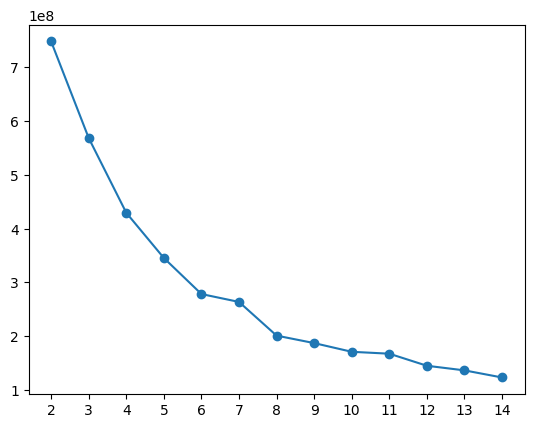

In [406]:
plt.plot(range(2, 15), intertia_values, marker='o')
plt.xticks(range(2, 15))
plt.show()

## create clusters

In [402]:
cluster_model = KMeans(n_clusters=7)
state_events['cluster'] = cluster_model.fit_predict(state_events)
state_events['cluster'].value_counts()

cluster
3    29
2    15
5     9
1     6
0     4
4     3
6     3
Name: count, dtype: int64

## sample states in each cluster

In [407]:
# larger clusters
larger_clusters = state_events[['cluster']].groupby('cluster').filter(lambda c: len(c) >= 5)
larger_clusters[['cluster']].groupby('cluster').sample(5)

,cluster
IOWA,1
COLORADO,1
MINNESOTA,1
SOUTH DAKOTA,1
WISCONSIN,1
ILLINOIS,2
VIRGINIA,2
KENTUCKY,2
PENNSYLVANIA,2
FLORIDA,2


In [408]:
# remaining clusters
smaller_clusters = state_events[['cluster']].groupby('cluster').filter(lambda c: len(c) < 5)
smaller_clusters[['cluster']].sort_values(by='cluster')

,cluster
ARIZONA,0
ARKANSAS,0
CALIFORNIA,0
LOUISIANA,0
ATLANTIC NORTH,4
ATLANTIC SOUTH,4
GULF OF MEXICO,4
KANSAS,6
OKLAHOMA,6
TEXAS,6


## weather events per cluster

In [ ]:
# select top 5 events from each state, then select events shared by at least 3 states
for c in range(0,7):
    # get states in current cluster
    cluster_states = state_events[state_events['cluster'] == c].index.tolist()
    all_events = []
    for s in cluster_states:
        # sort current state's events by count
        events_sorted = events_df[events_df['State'] == s][['Event', 'Count']].sort_values(by='Count', ascending=False)
        # add top 5 events to current cluster event list
        for item in events_sorted[:5]['Event'].values.tolist():
            all_events.append(item)
       
    shared_event_count = pd.DataFrame(all_events).value_counts().to_frame()
    shared_event_count = shared_event_count.rename_axis('Event')
    # select events with shared by >= 3 states
    print(f'cluster {c}: \n {shared_event_count[shared_event_count['count'] >= 3]} \n')

cluster 0: 
                    count
Event                   
Flash Flood            3
Excessive Heat         3
Thunderstorm Wind      3
Heat                   3 

cluster 1: 
                    count
Event                   
Hail                   6
Thunderstorm Wind      6
Winter Weather         4
High Wind              3
Winter Storm           3
Flood                  3 

cluster 2: 
                    count
Event                   
Thunderstorm Wind     15
Hail                  13
Flash Flood           12
Winter Weather         8
Flood                  7
Winter Storm           4
Tornado                3
Drought                3
Strong Wind            3 

cluster 3: 
                           count
Event                          
Flash Flood                  12
Thunderstorm Wind            11
Heavy Snow                   10
High Wind                     9
Waterspout                    9
Marine Thunderstorm Wind      9
Winter Weather                8
Marine Hail                  